<a href="https://colab.research.google.com/github/umar-1623/EE-501-AI/blob/image-classification-using-deep-learning/image_classification_with_Deep_Learning_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**prerequisite**

Learn about the [TensorFlow](https://www.beoptimized.be/pdf/TensorFlow2Cheatsheet.pdf) Python library.

# Introduction to Pre-trained Models

**What are Pre-trained Models?**

Pre-trained models are deep neural networks that have already been trained on large datasets (most commonly, ImageNet).

Rather than training from scratch, we can use these models for inference or transfer learning.

They are powerful because they have “learned” to extract rich features from images.

**Popular Pre-trained Models:**

VGG16 / VGG19: Simple architecture with many layers of 3x3 convolutions, known for its depth.

ResNet (e.g., ResNet50): Uses “residual connections” or “skip connections” to train much deeper networks efficiently.

DenseNet: Each layer receives input from all previous layers, which encourages feature reuse and mitigates the vanishing gradient problem.

**What Dataset Were They Trained On?**

These models are most often trained on the ImageNet dataset.

ImageNet is a huge dataset with:

1.2 million+ images

1,000 classes (categories), e.g., dog, cat, airplane, car, etc.

When you load a model with pretrained=True in PyTorch, it means the model weights come from training on ImageNet.

**How Do They Classify?**

The model receives an image, processes it through layers, and outputs a vector of 1,000 numbers—each number representing the probability of one class.

The class with the highest probability is the predicted label.

 Load and Summarize VGG16

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16

model_vgg = VGG16(weights='imagenet', input_shape=(224, 224, 3))
model_vgg.trainable = False
model_vgg.summary()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 138,357,544 (527.79 MB)

Load and Summarize ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

model_resnet = ResNet50(weights='imagenet', input_shape=(224, 224, 3))
model_resnet.summary()


102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

Load and Summarize DenseNet121

In [ ]:
from tensorflow.keras.applications import DenseNet121

model_dense = DenseNet121(weights='imagenet', input_shape=(224, 224, 3))
model_dense.summary()


33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,062,504 (30.76 MB)

 Trainable params: 7,978,856 (30.44 MB)

 Non-trainable params: 83,648 (326.75 KB)

**ImageNet**

Full ImageNet dataset: Contains over 20,000 categories (synsets) with millions of images. This is the entire WordNet hierarchy covered by ImageNet.

ImageNet Large Scale Visual Recognition Challenge (ILSVRC) subset: The most widely used subset for training models like VGG16, ResNet, DenseNet contains exactly 1,000 object classes (categories), with about 1.2 million training images.

[detail of imageNet](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a)

**Quick Inference with Pre-trained Models**



**Inference with Pre-trained VGG16**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


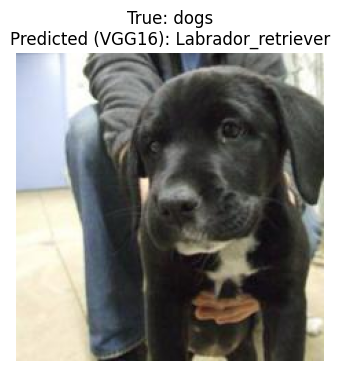

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


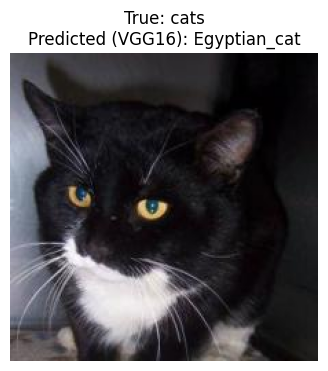

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


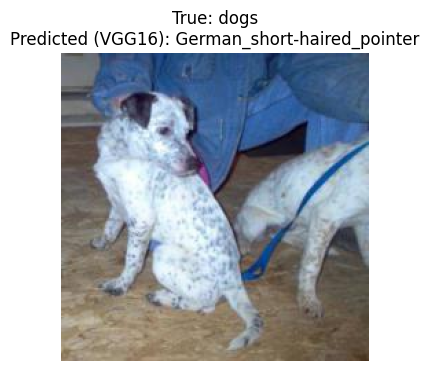

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


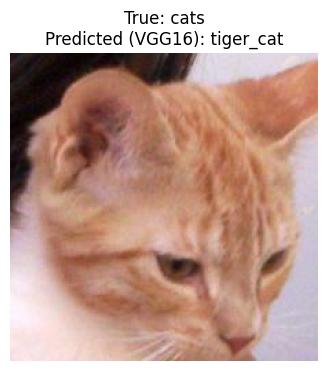

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


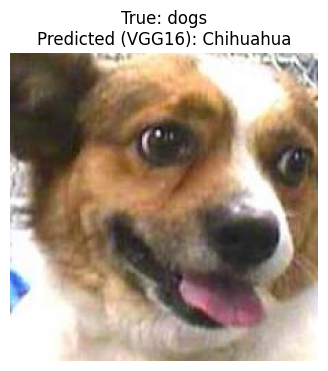

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

# 1. Point to your dataset root
data_dir = r"/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification"

# 2. Collect (filepath, true_label_name) pairs
filepaths = []
true_labels = []

# We assume each subfolder under `data_dir` is one class:
# e.g. data_dir/
#        ├── cat/
#        │      ├── cat01.jpg
#        │      └── cat02.png
#        └── dog/
#               ├── dogA.jpg
#               └── dogB.png

for folder_name in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for fname in os.listdir(folder_path):
        # (optionally) skip non‐image files:
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue

        filepaths.append(os.path.join(folder_path, fname))
        true_labels.append(folder_name)

# 3. Utility to pick N random indices
def pick_random_indices(n=5):
    return random.sample(range(len(filepaths)), k=n)

# 4. Load pretrained VGG16 (ImageNet weights)
model = VGG16(weights="imagenet")

# 5. Pick 5 random images to display
indices = pick_random_indices(n=5)

for idx in indices:
    img_path = filepaths[idx]
    true_label = true_labels[idx]

    # a. Load + resize to 224×224
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)            # shape: (224,224,3)
    x = tf.expand_dims(x, axis=0)                # shape: (1,224,224,3)
    x = preprocess_input(x)                      # VGG16 preprocessing

    # b. Run prediction
    preds = model.predict(x)                     # shape: (1,1000)
    top_pred_name = decode_predictions(preds, top=1)[0][0][1]

    # c. Display with True vs. Predicted text
    plt.figure(figsize=(4,4))
    plt.imshow(keras_image.load_img(img_path, target_size=(224,224)))
    plt.title(f"True: {true_label}\nPredicted (VGG16): {top_pred_name}")
    plt.axis("off")
    plt.show()


**Inference with ResNet50**

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


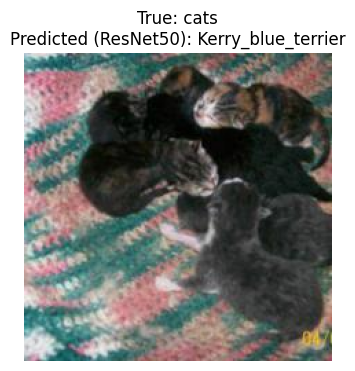

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


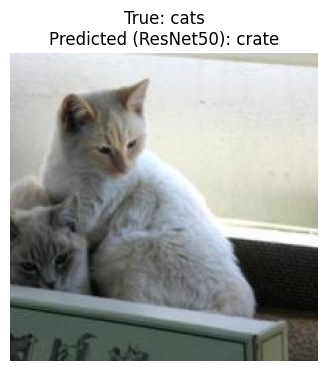

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


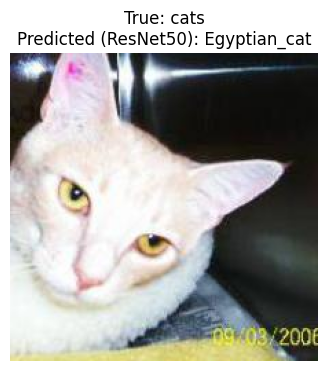

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


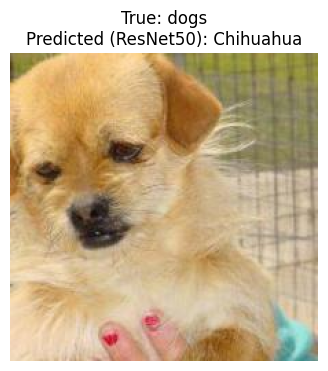

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


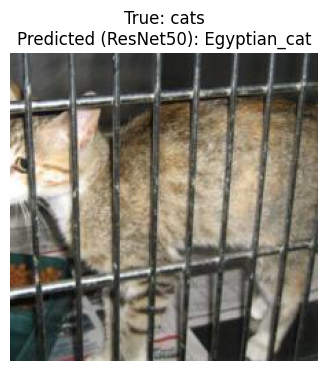

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

# 1. Point to your dataset root
data_dir = r"/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification"

# 2. Gather (filepath, true_label_name) pairs
filepaths = []
true_labels = []

for folder_name in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for fname in os.listdir(folder_path):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue
        filepaths.append(os.path.join(folder_path, fname))
        true_labels.append(folder_name)

# 3. Utility to pick N random indices
def pick_random_indices(n=5):
    return random.sample(range(len(filepaths)), k=n)

# 4. Load pretrained ResNet50 (ImageNet weights)
model = ResNet50(weights="imagenet")

# 5. Pick 5 random images
indices = pick_random_indices(n=5)

for idx in indices:
    img_path = filepaths[idx]
    true_label = true_labels[idx]

    # a) Load + resize to 224×224 (ResNet50 expects the same size)
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)
    x = tf.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # b) Run prediction
    preds = model.predict(x)
    top_pred_name = decode_predictions(preds, top=1)[0][0][1]

    # c) Display with True vs. Predicted text
    plt.figure(figsize=(4,4))
    plt.imshow(keras_image.load_img(img_path, target_size=(224,224)))
    plt.title(f"True: {true_label}\nPredicted (ResNet50): {top_pred_name}")
    plt.axis("off")
    plt.show()


**Inference with DenseNet121**

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


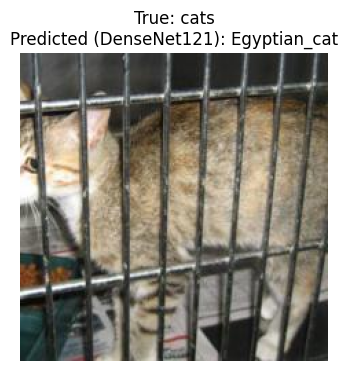

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


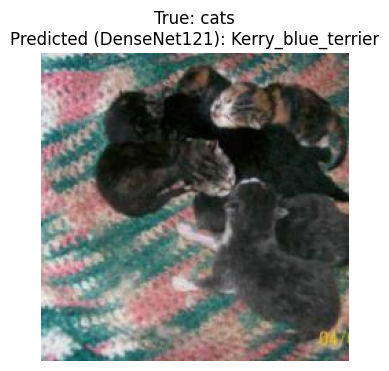

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


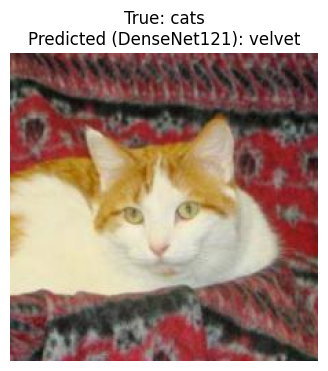

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


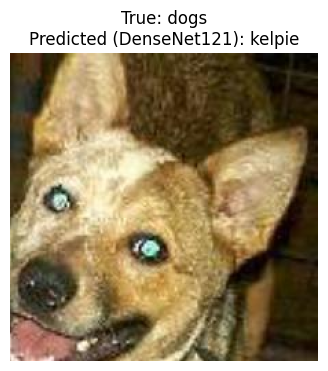

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


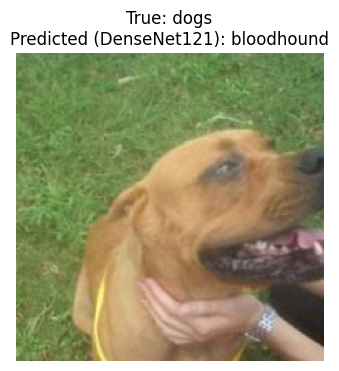

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input, decode_predictions

# 1. Point to your dataset root
data_dir = r"/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification"

# 2. Gather (filepath, true_label_name) pairs
filepaths = []
true_labels = []

for folder_name in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for fname in os.listdir(folder_path):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue
        filepaths.append(os.path.join(folder_path, fname))
        true_labels.append(folder_name)

# 3. Utility to pick N random indices
def pick_random_indices(n=5):
    return random.sample(range(len(filepaths)), k=n)

# 4. Load pretrained DenseNet121 (ImageNet weights)
model = DenseNet121(weights="imagenet")

# 5. Pick 5 random images
indices = pick_random_indices(n=5)

for idx in indices:
    img_path = filepaths[idx]
    true_label = true_labels[idx]

    # a) Load + resize to 224×224 (DenseNet121 expects 224×224×3)
    img = keras_image.load_img(img_path, target_size=(224, 224))
    x = keras_image.img_to_array(img)
    x = tf.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # b) Run prediction
    preds = model.predict(x)
    top_pred_name = decode_predictions(preds, top=1)[0][0][1]

    # c) Display with True vs. Predicted text
    plt.figure(figsize=(4,4))
    plt.imshow(keras_image.load_img(img_path, target_size=(224,224)))
    plt.title(f"True: {true_label}\nPredicted (DenseNet121): {top_pred_name}")
    plt.axis("off")
    plt.show()


#  <a name="finetune"></a>Fine-tuning Pre-trained Models

Load your data (from directories you specify)

Fine-tune VGG16 (using include_top=False and your own classification head)

Train and validate the model

Evaluate on the test set and print results

Show some random test predictions

[Food classification dataset](https://www.kaggle.com/datasets/harishkumardatalab/food-image-classification-dataset)

first we have to split the data into train, validation and testset.



In [ ]:
# this script will run one time to just split the data into train, validation and test sets.

import os
import random
import shutil
from math import floor

def split_dataset(main_folder_path, val_ratio=0.15, test_ratio=0.15):
    # Create output directories for train, val, test
    train_dir = os.path.join(main_folder_path, 'train')
    val_dir = os.path.join(main_folder_path, 'val')
    test_dir = os.path.join(main_folder_path, 'test')

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # List all class folders in main folder (ignore train/val/test if they already exist)
    classes = [d for d in os.listdir(main_folder_path) if os.path.isdir(os.path.join(main_folder_path, d)) and d not in ['train', 'val', 'test']]

    for cls in classes:
        cls_path = os.path.join(main_folder_path, cls)
        files = os.listdir(cls_path)
        files = [f for f in files if os.path.isfile(os.path.join(cls_path, f))]

        random.shuffle(files)

        n_total = len(files)
        n_val = floor(val_ratio * n_total)
        n_test = floor(test_ratio * n_total)
        n_train = n_total - n_val - n_test

        train_files = files[:n_train]
        val_files = files[n_train:n_train + n_val]
        test_files = files[n_train + n_val:]

        # Create class subfolders inside train, val, test
        train_cls_dir = os.path.join(train_dir, cls)
        val_cls_dir = os.path.join(val_dir, cls)
        test_cls_dir = os.path.join(test_dir, cls)

        os.makedirs(train_cls_dir, exist_ok=True)
        os.makedirs(val_cls_dir, exist_ok=True)
        os.makedirs(test_cls_dir, exist_ok=True)

        # Move files
        for f in train_files:
            shutil.move(os.path.join(cls_path, f), os.path.join(train_cls_dir, f))
        for f in val_files:
            shutil.move(os.path.join(cls_path, f), os.path.join(val_cls_dir, f))
        for f in test_files:
            shutil.move(os.path.join(cls_path, f), os.path.join(test_cls_dir, f))

        # After moving files, remove the now empty original class folder
        if not os.listdir(cls_path):
            os.rmdir(cls_path)

        print(f"Class '{cls}': {n_train} train, {n_val} val, {n_test} test files moved.")

# Example usage:
main_folder_path = '/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification'  # Change this to your actual path
split_dataset(main_folder_path)

Class 'apple_pie': 700 train, 150 val, 150 test files moved.
Class 'Baked Potato': 1050 train, 225 val, 225 test files moved.
Class 'burger': 233 train, 49 val, 49 test files moved.
Class 'butter_naan': 215 train, 46 val, 46 test files moved.
Class 'chai': 242 train, 51 val, 51 test files moved.
Class 'chapati': 229 train, 49 val, 49 test files moved.
Class 'cheesecake': 700 train, 150 val, 150 test files moved.
Class 'chicken_curry': 700 train, 150 val, 150 test files moved.
Class 'chole_bhature': 264 train, 56 val, 56 test files moved.
Class 'Crispy Chicken': 1050 train, 225 val, 225 test files moved.
Class 'dal_makhani': 207 train, 44 val, 44 test files moved.
Class 'Donut': 1050 train, 225 val, 225 test files moved.
Class 'dhokla': 173 train, 36 val, 36 test files moved.
Class 'fried_rice': 246 train, 52 val, 52 test files moved.
Class 'Fries': 1050 train, 225 val, 225 test files moved.
Class 'Hot Dog': 1084 train, 232 val, 232 test files moved.
Class 'ice_cream': 700 train, 150 va

In [ ]:
# --- Import Libraries ---
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# ==== USER: Specify your paths here ====
TRAIN_DIR = '/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification/train'
VAL_DIR   = '/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification/val'
TEST_DIR  = '/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- Load Data ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Detected classes:", class_names)

# --- Preprocessing for VGG16 ---
from tensorflow.keras.applications.vgg16 import preprocess_input

def preprocess_dataset(dataset):
    return dataset.map(lambda x, y: (preprocess_input(x), y))

train_ds = preprocess_dataset(train_ds)
val_ds = preprocess_dataset(val_ds)
test_ds = preprocess_dataset(test_ds)

# --- Build Model (VGG16 base + custom head) ---
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base for transfer learning (can unfreeze for fine-tuning later)


print('Base Model summary')
base_model.summary()

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


print('propsed model summary')
model.summary()

# --- Train Model ---
EPOCHS = 1  # You can change as needed
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

# --- Optionally Unfreeze Some Layers for Fine-Tuning ---
# base_model.trainable = True
# model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),  # Lower LR for fine-tuning
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])
# history_finetune = model.fit(
#     train_ds,
#     epochs=EPOCHS,
#     validation_data=val_ds
# )

# --- Evaluate on Test Set ---
loss, acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# --- Show Random Predictions from Test Set ---
all_images = []
all_labels = []
for images, labels in test_ds.unbatch():
    all_images.append(images.numpy().astype('uint8'))
    all_labels.append(labels.numpy())

num_examples = min(7, len(all_images))
indices = random.sample(range(len(all_images)), num_examples)

for idx in indices:
    img = all_images[idx]
    true_label = all_labels[idx]
    x = tf.expand_dims(img, 0)
    x = preprocess_input(tf.cast(x, tf.float32))
    preds = model.predict(x)
    pred_class = np.argmax(preds)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}, Predicted: {class_names[pred_class]}")
    plt.axis('off')
    plt.show()

# --- Save Model ---
#model.save('/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classificationvgg16_finetuned.h5')
#print("Model saved to /content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classificationvgg16_finetuned.h5")


Found 16729 files belonging to 34 classes.
Found 3572 files belonging to 34 classes.
Found 3572 files belonging to 34 classes.
Detected classes: ['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'burger', 'butter_naan', 'chai', 'chapati', 'cheesecake', 'chicken_curry', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'ice_cream', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'omelette', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa', 'sushi']
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model summary


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,784,738 (56.40 MB)

 Trainable params: 70,050 (273.63 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

241/523 ━━━━━━━━━━━━━━━━━━━━ 35:14 7s/step - accuracy: 0.1057 - loss: 6.1224

**prerequist**

Learn about [pytorch](https://docs.pytorch.org/tutorials/beginner/ptcheat.html) python library.

In [ ]:
import os

new_dir = '/content/drive/MyDrive/AI Course/umar/lecture_09/data/YOLO/'
os.chdir(new_dir)

print("Current working directory:", os.getcwd())


Current working directory: /content/drive/MyDrive/AI Course/umar/lecture_09/data/YOLO


**Inference with YOLOv8 (Pre-trained Model)**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 


image 1/1 /content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/cats/cat806.jpg: 224x224 tabby 0.19, Chihuahua 0.17, chow 0.05, basenji 0.05, tiger_cat 0.05, 3.9ms
Speed: 34.0ms preprocess, 3.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


100%|██████████| 755k/755k [00:00<00:00, 18.1MB/s]


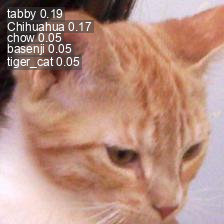


image 1/1 /content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/cats/cat818.jpg: 224x224 prison 0.28, pick 0.14, mousetrap 0.09, dishwasher 0.03, combination_lock 0.03, 3.7ms
Speed: 2.8ms preprocess, 3.7ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


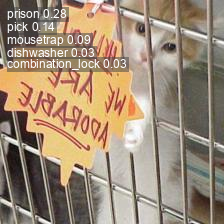


image 1/1 /content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/dogs/dog948.jpg: 224x224 titi 0.24, bull_mastiff 0.21, Brabancon_griffon 0.13, African_hunting_dog 0.09, Leonberg 0.08, 3.4ms
Speed: 3.1ms preprocess, 3.4ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


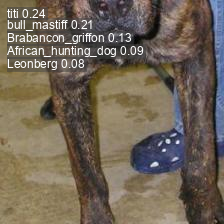


image 1/1 /content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/dogs/dog955.jpg: 224x224 Great_Dane 0.44, German_short-haired_pointer 0.30, curly-coated_retriever 0.06, Labrador_retriever 0.05, Mexican_hairless 0.04, 3.4ms
Speed: 3.0ms preprocess, 3.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


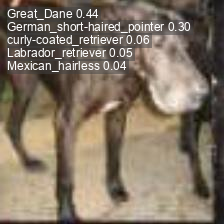

In [ ]:
from ultralytics import YOLO

# Load YOLOv8 pre-trained model
model = YOLO('yolov8n-cls.pt')  # 'n' is the nano version (smallest)

# Run inference
results = model('/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/cats/cat806.jpg')
# results is a list, so call .show() on the first element (assuming only one image)
results[0].show()

results = model('/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/cats/cat818.jpg')
# results is a list, so call .show() on the first element (assuming only one image)
results[0].show()

results = model('/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/dogs/dog948.jpg')
# results is a list, so call .show() on the first element (assuming only one image)
results[0].show()

results = model('/content/drive/MyDrive/AI_Course/umar/lecture_09/data/binary classification/dogs/dog955.jpg')
# results is a list, so call .show() on the first element (assuming only one image)
results[0].show()


B. Training a Custom YOLOv8 Model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data=r"/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification",
    epochs=20,
    imgsz=224,
    batch=16,
    name="food_cls_experiment"
)


Ultralytics 8.3.150 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=food_cls_experiment, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

100%|██████████| 5.35M/5.35M [00:00<00:00, 93.8MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.8±0.4 ms, read: 0.0±0.0 MB/s, size: 8.6 KB)


train: Scanning /content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification/train... 16729 images, 0 corrupt: 100%|██████████| 16729/16729 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 1.2±1.1 ms, read: 0.0±0.0 MB/s, size: 10.4 KB)


val: Scanning /content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification/val... 1840 images, 0 corrupt:  52%|█████▏    | 1840/3572 [12:56<13:14,  2.18it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
val: Scanning /content/drive/MyDrive/AI_Course/umar/lecture_09/data/YOLO/Food_Classification/val... 3002 images, 0 corrupt:  84%|████████▍ | 3002/3572 [23:26<05:19,  1.79it/s]

For other classification models, please refer to this [link](https://medium.com/@umar.sadique/deep-learning-models-for-image-classification-89c6e471b0cd).